In [19]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

# =====================================
# Paths
# =====================================
ROOT_DIR = Path("results") / "activity_recognition"
OUTPUT_DIR = ROOT_DIR / "paper_comparison_plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_CSV_PATH = ROOT_DIR / "metrics_best_final_val_summary_from_json.csv"

METRIC_NAME_MAP = {
    "loss": "Loss",
    "acc": "Accuracy",
    "f1": "F1",
    "iou": "IoU",
    "precision": "Precision",
    "recall": "Recall",
}

METRIC_ORDER = ["Loss", "Accuracy", "F1", "IoU", "Precision", "Recall"]
PROCESS_PART_ORDER = [
    "machine_and_movement",
    "movement",
]

# =====================================
# Plot style
# =====================================
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# =====================================
# Helpers
# =====================================
def safe_name(text: str) -> str:
    return str(text).replace("/", "_").replace("\\", "_").replace(" ", "_")

def metric_direction(metric_key: str) -> str:
    return "min" if metric_key == "loss" else "max"

def get_best_epoch_index(values, metric_key: str):
    if not values:
        return None
    series = pd.Series(values, dtype="float64")
    return int(series.idxmin() if metric_direction(metric_key) == "min" else series.idxmax())

def load_metrics_rows() -> list[dict]:
    rows = []
    for history_path in sorted(ROOT_DIR.rglob("training_history.json")):
        label_name = history_path.parent.name
        process_part = history_path.parent.parent.name
        eval_path = history_path.parent / "evaluation_metrics.json"

        if not eval_path.exists():
            continue

        history = json.loads(history_path.read_text())
        evaluation = json.loads(eval_path.read_text())
        val_history = history.get("val_history", {})
        final_val_metrics = evaluation.get("val", {})
        last_epoch = len(val_history.get("loss", []))

        for metric_key, metric_label in METRIC_NAME_MAP.items():
            best_epoch = get_best_epoch_index(val_history.get(metric_key, []), metric_key)
            best_val = None
            if best_epoch is not None:
                best_val = float(val_history[metric_key][best_epoch])

            rows.append({
                "Process Part": process_part,
                "Label": label_name,
                "Metric": metric_label,
                "Best Val": best_val,
                "Best Epoch": None if best_epoch is None else best_epoch + 1,
                "Last Epoch": last_epoch if last_epoch > 0 else None,
                "Final Val": float(final_val_metrics.get(metric_key)) if metric_key in final_val_metrics else None,
                "History Path": str(history_path),
                "Evaluation Path": str(eval_path),
            })
    return rows

# =====================================
# Load current JSON results
# =====================================
summary_df = pd.DataFrame(load_metrics_rows())

if summary_df.empty:
    raise ValueError(f"No activity-recognition JSON results found under {ROOT_DIR}")

summary_df = summary_df.sort_values(["Process Part", "Label", "Metric"]).reset_index(drop=True)
summary_df.to_csv(SUMMARY_CSV_PATH, index=False)
display(summary_df)

print(f"Saved summary to: {SUMMARY_CSV_PATH}")

# =====================================
# Plot best validation values like the grouped comparison figure
# =====================================
LABEL_ORDER = [
    "Bending",
    "Clamping",
    "De-Clamping",
    "Mandrel Extraction",
    "Multiclass",
]

PROCESS_PART_DISPLAY = {
    "machine_and_movement": "Machine and Movement",
    "movement": "Movement",
}

PROCESS_PART_COLORS = {
    "machine_and_movement": "blue",
    "movement": "red",
}

available_metrics = summary_df["Metric"].dropna().unique().tolist()
final_metric_order = [m for m in METRIC_ORDER if m in available_metrics]
final_metric_order += [m for m in available_metrics if m not in final_metric_order]

for metric in final_metric_order:
    metric_df = summary_df[summary_df["Metric"] == metric].copy()
    metric_df = metric_df.dropna(subset=["Best Val"])
    if metric_df.empty:
        continue

    pivot = metric_df.pivot_table(
        index="Label",
        columns="Process Part",
        values="Best Val",
        aggfunc="first",
    )
    pivot = pivot.reindex([label for label in LABEL_ORDER if label in pivot.index])


,Process Part,Label,Metric,Best Val,Best Epoch,Last Epoch,Final Val,History Path,Evaluation Path
0,machine_and_movement,Bending,Accuracy,0.997382,17,21,0.997382,results/activity_recognition/machine_and_movem...,results/activity_recognition/machine_and_movem...
1,machine_and_movement,Bending,F1,0.997383,17,21,0.997383,results/activity_recognition/machine_and_movem...,results/activity_recognition/machine_and_movem...
2,machine_and_movement,Bending,IoU,0.994782,17,21,0.994782,results/activity_recognition/machine_and_movem...,results/activity_recognition/machine_and_movem...
3,machine_and_movement,Bending,Loss,0.005882,17,21,0.005882,results/activity_recognition/machine_and_movem...,results/activity_recognition/machine_and_movem...
4,machine_and_movement,Bending,Precision,0.997384,17,21,0.997384,results/activity_recognition/machine_and_movem...,results/activity_recognition/machine_and_movem...
5,machine_and_movement,Bending,Recall,0.997382,17,21,0.997382,results/activity_recognition/machine_and_movem...,results/activity_recognition/machine_and_movem...
6,machine_and_movement,Clamping,Accuracy,0.997734,20,25,0.997715,results/activity_recognition/machine_and_movem...,results/activity_recognition/machine_and_movem...
7,machine_and_movement,Clamping,F1,0.997733,20,25,0.997716,results/activity_recognition/machine_and_movem...,results/activity_recognition/machine_and_movem...
8,machine_and_movement,Clamping,IoU,0.995488,20,25,0.995454,results/activity_recognition/machine_and_movem...,results/activity_recognition/machine_and_movem...
9,machine_and_movement,Clamping,Loss,0.005501,21,25,0.005501,results/activity_recognition/machine_and_movem...,results/activity_recognition/machine_and_movem...


Saved summary to: results/activity_recognition/metrics_best_final_val_summary_from_json.csv


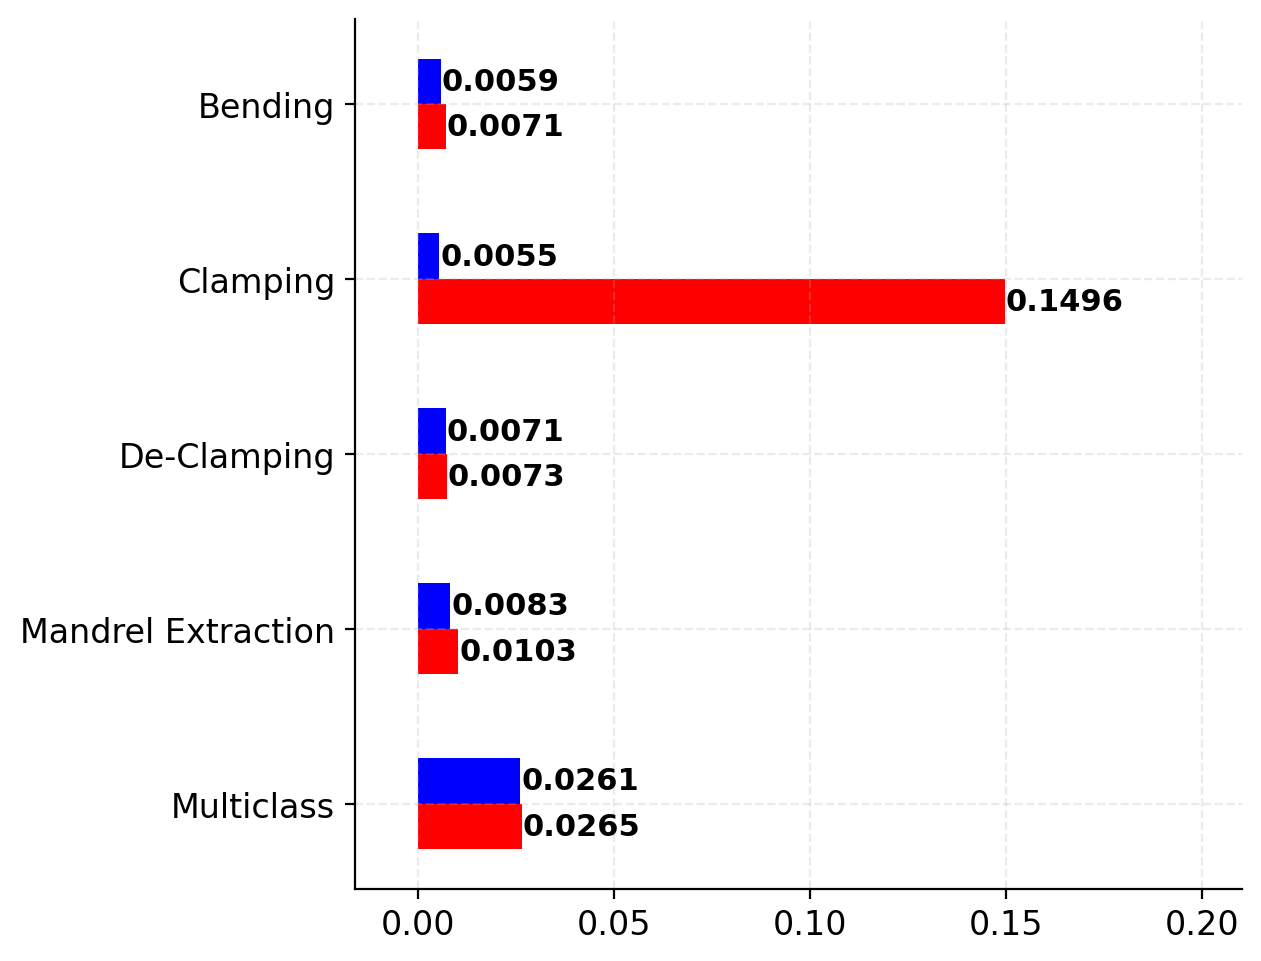

Saved plot to: results/activity_recognition/paper_comparison_plots/final_val_grouped_Loss.pdf


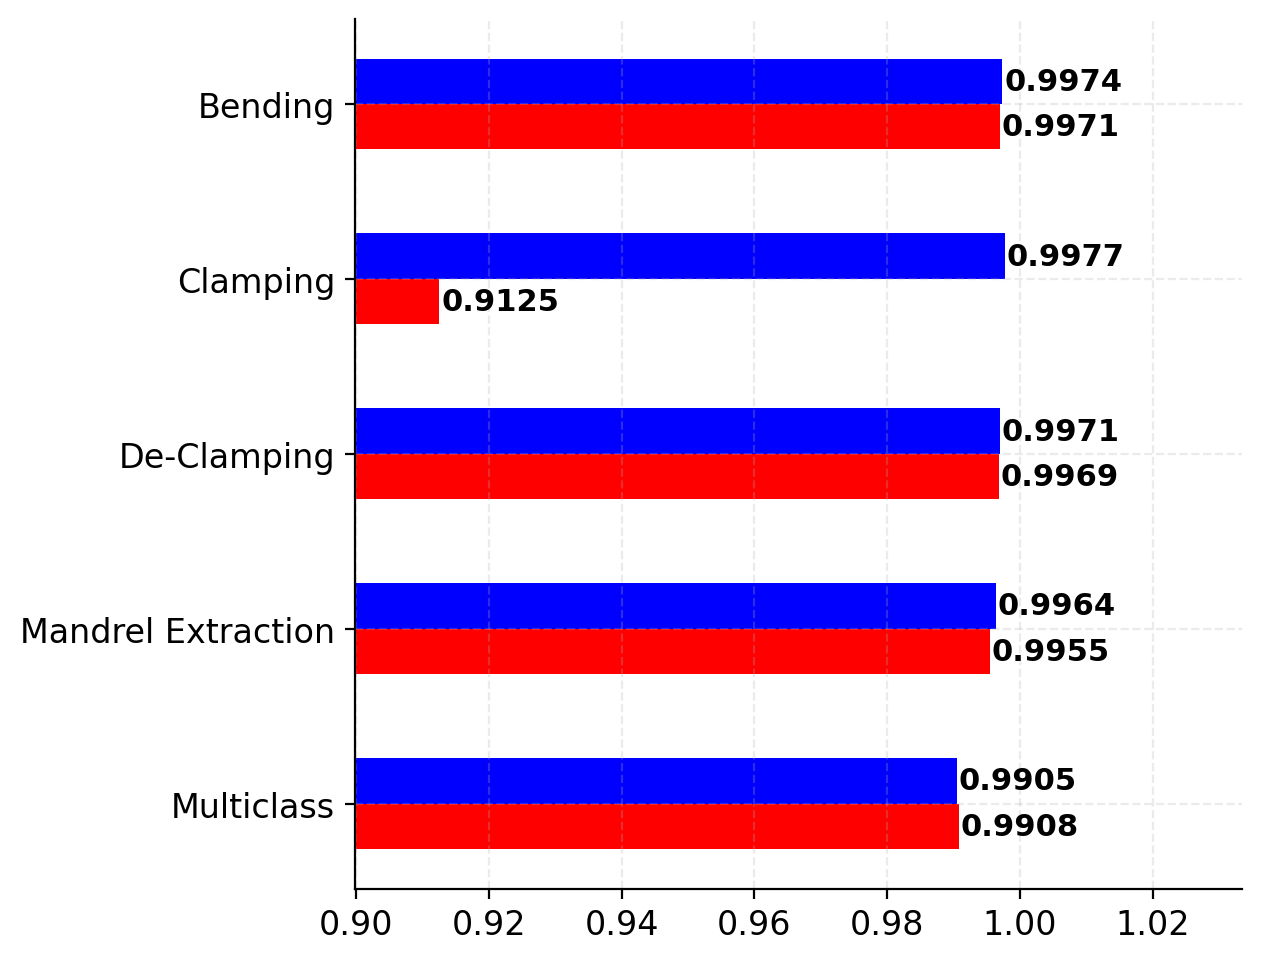

Saved plot to: results/activity_recognition/paper_comparison_plots/final_val_grouped_Accuracy.pdf


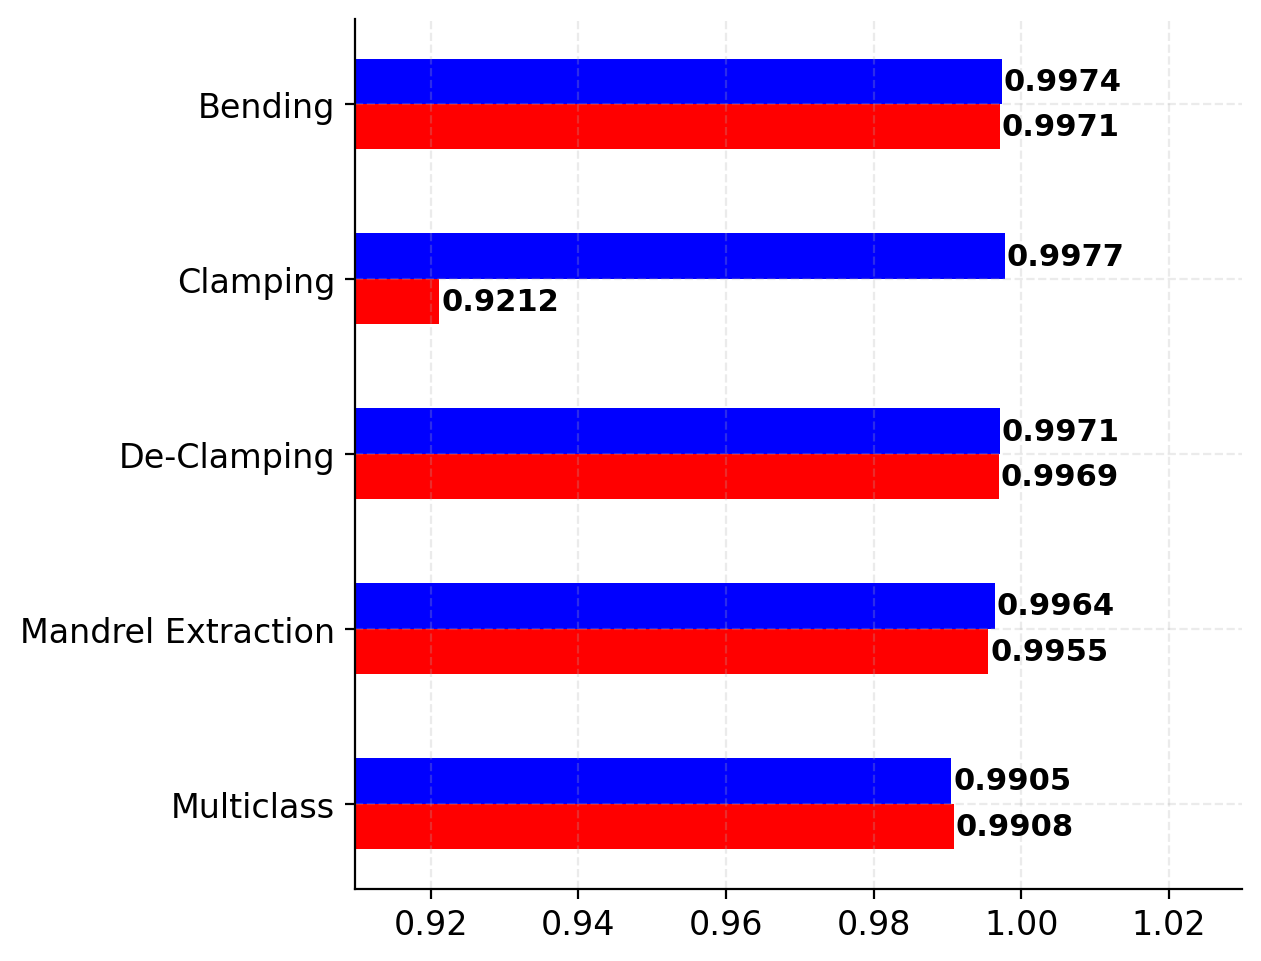

Saved plot to: results/activity_recognition/paper_comparison_plots/final_val_grouped_F1.pdf


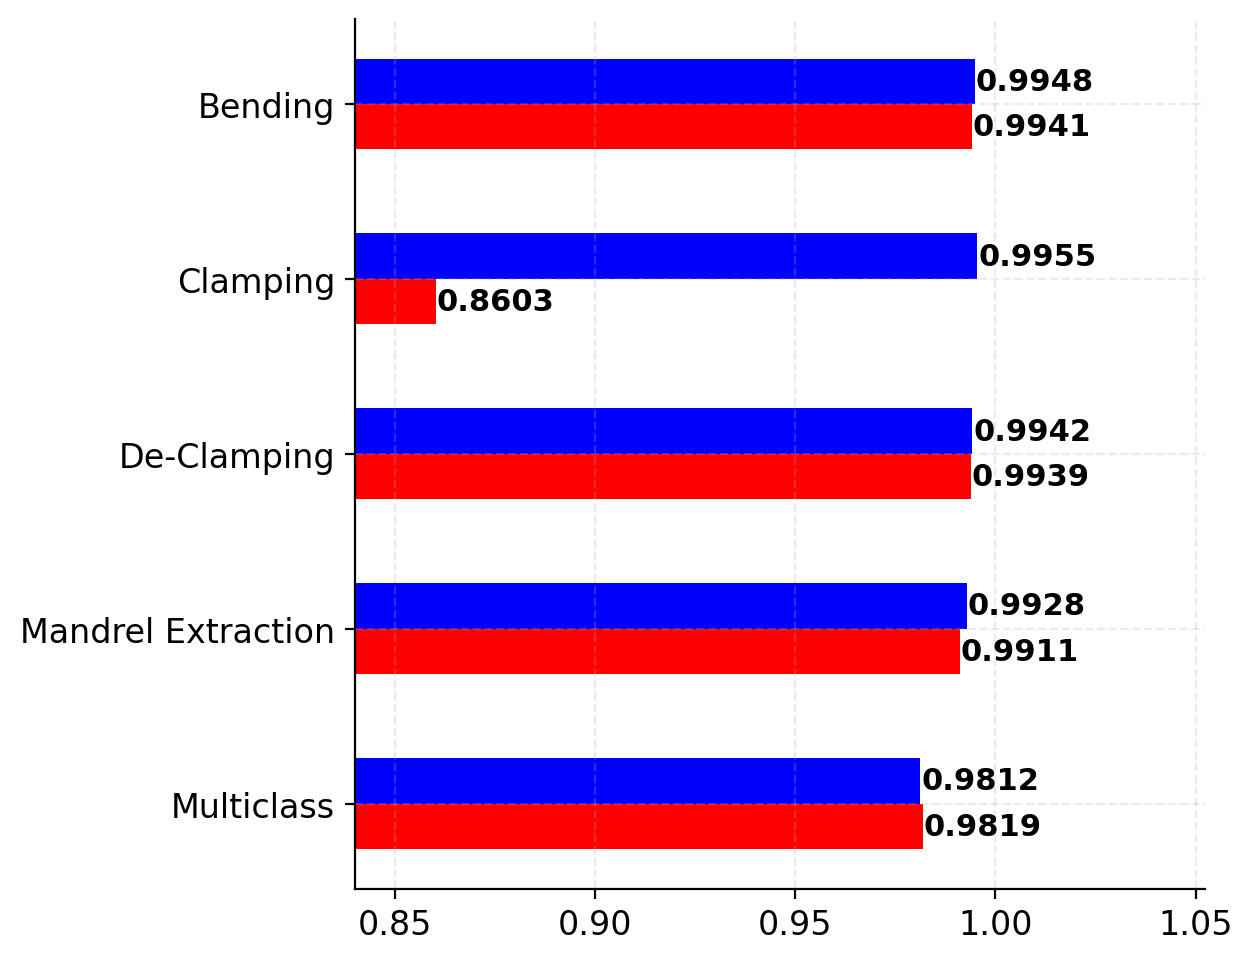

Saved plot to: results/activity_recognition/paper_comparison_plots/final_val_grouped_IoU.pdf


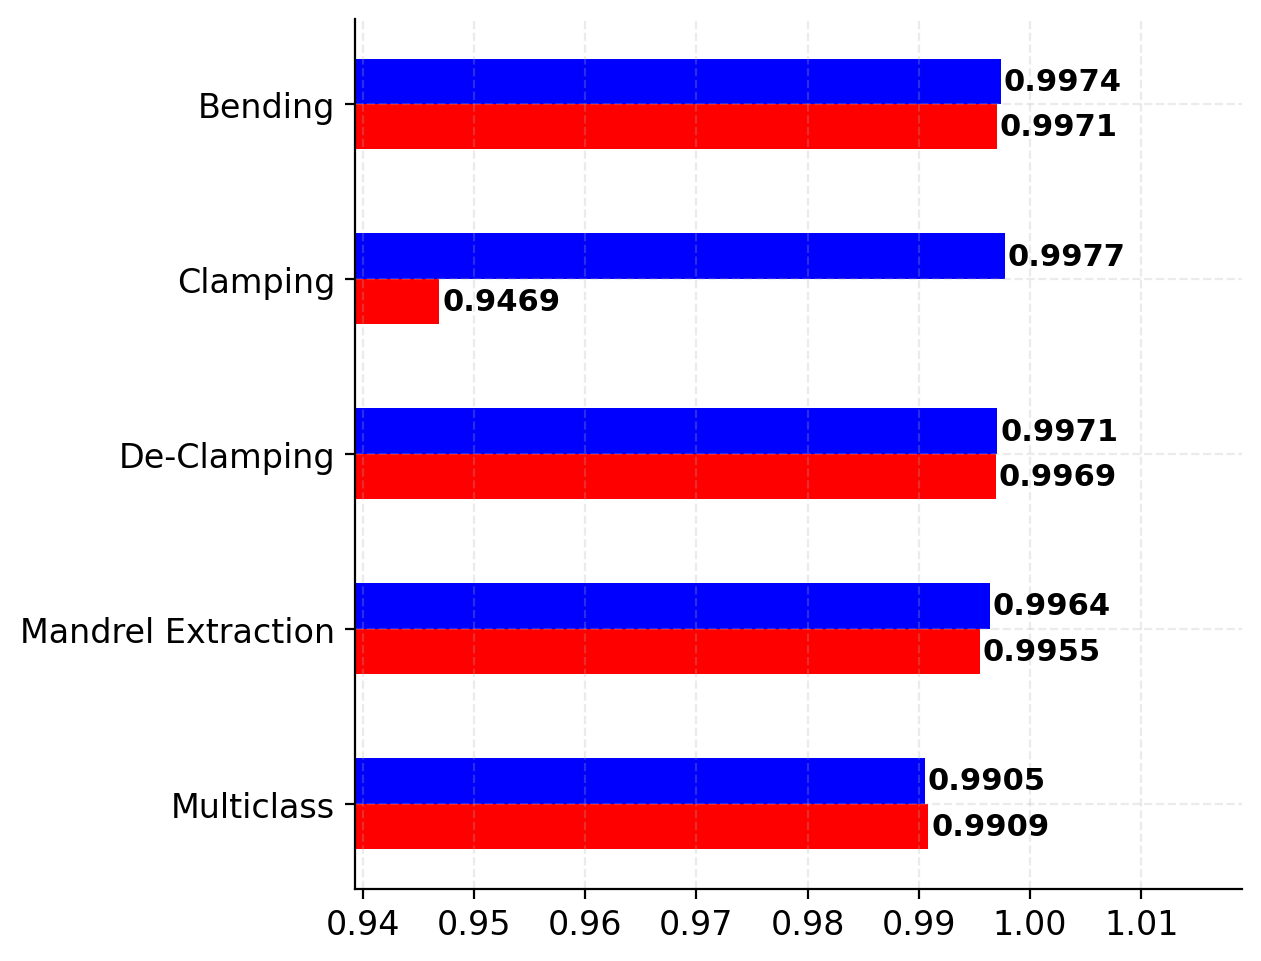

Saved plot to: results/activity_recognition/paper_comparison_plots/final_val_grouped_Precision.pdf


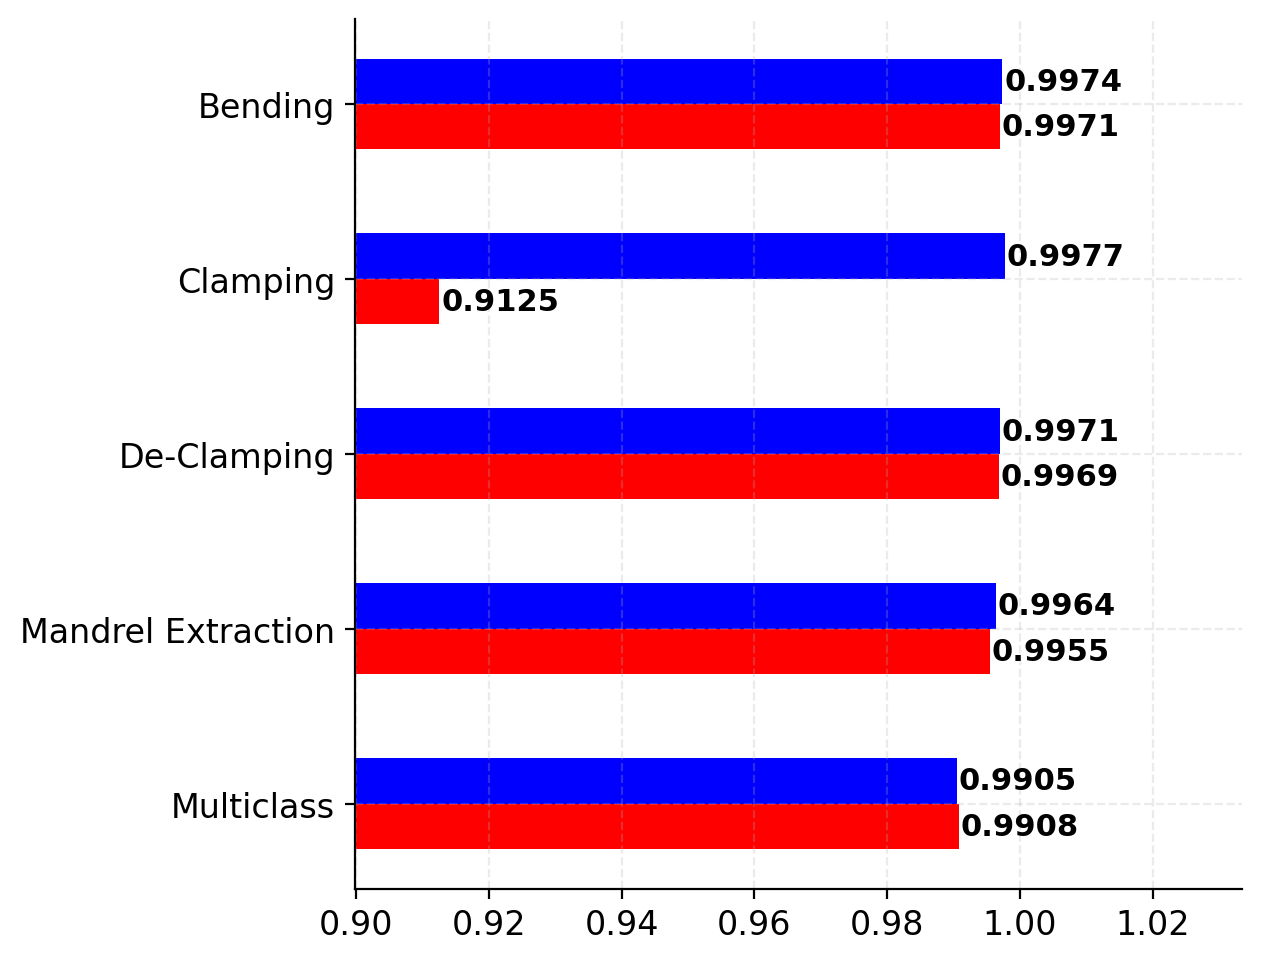

Saved plot to: results/activity_recognition/paper_comparison_plots/final_val_grouped_Recall.pdf


In [20]:
# =====================================
# Plot final validation values with the same grouped layout
# =====================================
for metric in final_metric_order:
    metric_df = summary_df[summary_df["Metric"] == metric].copy()
    metric_df = metric_df.dropna(subset=["Final Val"])
    if metric_df.empty:
        continue

    pivot = metric_df.pivot_table(
        index="Label",
        columns="Process Part",
        values="Final Val",
        aggfunc="first",
    )
    pivot = pivot.reindex([label for label in LABEL_ORDER if label in pivot.index])

    fig, ax = plt.subplots(figsize=(6.5, max(4.5, 1.0 * len(pivot))))

    y_positions = list(range(len(pivot.index)))
    bar_height = 0.26
    offsets = {
        "machine_and_movement": -bar_height / 2,
        "movement": bar_height / 2,
    }

    for process_part in PROCESS_PART_ORDER:
        if process_part not in pivot.columns:
            continue

        values = pivot[process_part]
        bars = ax.barh(
            [y + offsets[process_part] for y in y_positions],
            values,
            height=bar_height,
            color=PROCESS_PART_COLORS[process_part],
        )

        for idx, bar in enumerate(bars):
            value = values.iloc[idx]
            if pd.isna(value):
                continue
            ax.text(
                bar.get_width() + 0.00025,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.4f}",
                va="center",
                ha="left",
                fontsize=11,
                fontweight="bold",
            )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(pivot.index)
    ax.invert_yaxis()
    ax.set_ylabel("")

    xmin = float(pivot.min().min())
    xmax = float(pivot.max().max())
    margin = max((xmax - xmin) * 0.15, 0.002)
    ax.set_xlim(xmin - margin, xmax + margin * 2.8)

    plt.tight_layout()
    save_path = OUTPUT_DIR / f"final_val_grouped_{safe_name(metric)}.pdf"
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved plot to: {save_path}")


In [21]:
# =====================================
# Build paper-style final validation table
# =====================================
MODEL_ORDER = [
    "Multiclass",
    "Bending",
    "Clamping",
    "De-Clamping",
    "Mandrel Extraction",
]

MODEL_DISPLAY = {
    "Multiclass": "Multiclass",
    "Bending": "Bending-Model",
    "Clamping": "Clamping-Model",
    "De-Clamping": "Declamping-Model",
    "Mandrel Extraction": "Mandrel Extraction-Model",
}

DATASET_DISPLAY = {
    "machine_and_movement": "Machine+Movement",
    "movement": "Movement-only",
}

METRIC_COLUMN_ORDER = [
    ("Accuracy", "Accuracy ↑"),
    ("F1", "F1 ↑"),
    ("IoU", "IoU ↑"),
    ("Loss", "Loss ↓"),
    ("Precision", "Precision ↑"),
    ("Recall", "Recall ↑"),
]

final_val_rows = []
for label in MODEL_ORDER:
    for process_part in PROCESS_PART_ORDER:
        row_df = summary_df[
            (summary_df["Label"] == label)
            & (summary_df["Process Part"] == process_part)
        ]
        if row_df.empty:
            continue

        metric_lookup = row_df.set_index("Metric")["Final Val"].to_dict()
        last_epoch = row_df["Last Epoch"].dropna().iloc[0] if row_df["Last Epoch"].notna().any() else None
        final_val_rows.append({
            "Model": MODEL_DISPLAY.get(label, label),
            "Dataset": DATASET_DISPLAY.get(process_part, process_part),
            "Last Epoch": int(last_epoch) if last_epoch is not None else None,
            **{
                display_name: metric_lookup.get(metric_name)
                for metric_name, display_name in METRIC_COLUMN_ORDER
            },
        })

paper_final_val_df = pd.DataFrame(final_val_rows)
paper_final_val_df


,Model,Dataset,Last Epoch,Accuracy ↑,F1 ↑,IoU ↑,Loss ↓,Precision ↑,Recall ↑
0,Multiclass,Machine+Movement,14,0.990507,0.990515,0.981247,0.026087,0.990546,0.990507
1,Multiclass,Movement-only,25,0.990819,0.990829,0.981856,0.026484,0.990865,0.990819
2,Bending-Model,Machine+Movement,21,0.997382,0.997383,0.994782,0.005882,0.997384,0.997382
3,Bending-Model,Movement-only,20,0.997050,0.997050,0.994122,0.007093,0.997051,0.997050
4,Clamping-Model,Machine+Movement,25,0.997715,0.997716,0.995454,0.005501,0.997717,0.997715
5,Clamping-Model,Movement-only,9,0.912547,0.921176,0.860298,0.149605,0.946903,0.912547
6,Declamping-Model,Machine+Movement,8,0.997070,0.997069,0.994161,0.007093,0.997068,0.997070
7,Declamping-Model,Movement-only,14,0.996914,0.996914,0.993855,0.007342,0.996915,0.996914
8,Mandrel Extraction-Model,Machine+Movement,15,0.996386,0.996389,0.992841,0.008341,0.996393,0.996386
9,Mandrel Extraction-Model,Movement-only,20,0.995507,0.995508,0.991113,0.010336,0.995509,0.995507
